## Регрессия - сгенерированный датасет
Создадим датасет для обучения линейной регрессии

In [1]:
# Импортируем scikit-learn модель для последующего сравнения (а также другие необходимые инструменты)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import r2_score
lin_reg_model = LinearRegression()

# Создаём искусстенный датасет (с линейным распределением признаков) (взят из тренеровки training_numpy)
import numpy as np
import pandas as pd
np.random.seed(42)
n = 200  # размер датасета

# Признаки
area = np.random.randint(30, 150, n)              # площадь дома (м²)
rooms = np.random.randint(1, 6, n)               # количество комнат
floor = np.random.randint(1, 10, n)              # этаж
age = np.random.randint(0, 50, n)                # возраст дома (лет)
distance_to_center = np.random.uniform(0.5, 15, n) # км до центра

# Целевая переменная: цена квартиры (в тыс. у.е.)
price = (2.5 * area 
         + 10 * rooms 
         - 0.3 * age 
         - 2.0 * distance_to_center 
         + np.random.normal(0, 15, n))  # шум

price = np.round(price, 0).astype(int)

# Собираем датафрейм
df = pd.DataFrame({
    'area': area,
    'rooms': rooms,
    'floor': floor,
    'age': age,
    'distance_to_center': distance_to_center,
    'price': price
})
y = np.array(df['price'])
X = np.array(df[[string for string in df if string != 'price']])
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, shuffle=True, test_size=0.2)
my_scaler = StandardScaler()
X_train_scaled = my_scaler.fit_transform(X_train)
X_test_scaled = my_scaler.transform(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

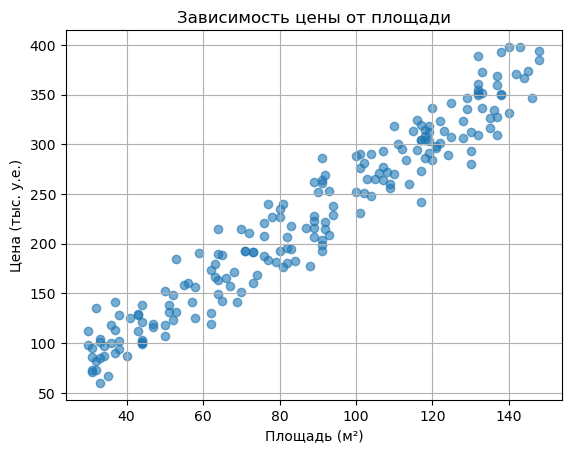

In [2]:
# График (можно убедиться, что есть линейная зависимость (на самом деле везде, но тут только цена от площади))
import matplotlib.pyplot as plt

plt.scatter(area, price, alpha=0.6)
plt.xlabel('Площадь (м²)')
plt.ylabel('Цена (тыс. у.е.)')
plt.title('Зависимость цены от площади')
plt.grid()
plt.show()    

In [3]:
class linear_regression_my_own:
    def __init__(self, lr = 0.4, l2= 0, n_steps = 1000):
        self.w = None
        self.b = None
        self.lr = lr
        self.l2 = l2
        self.n_steps = n_steps
    def fit(self, X, y):
        self.w = np.random.randn(X.shape[1])
        self.b = 0.0
        for i in range(self.n_steps):
            self.w = self.w + 2/X.shape[0] * self.lr*(X.T @ (y - self.predict(X))) - 2*self.lr*self.l2*self.w
            self.b = self.b + 2/X.shape[0] * self.lr*(np.array(y - self.predict(X))).sum()
    def predict(self, X_test):
        return X_test @ self.w + self.b
    def score(self, X, y_true):
        preds = self.predict(X)
        y_mean = y_true.mean()
        return 1 - ((y_true - preds)**2).sum()/((y_true - y_mean)**2).sum()
    def get_params(self, deep=True):
        return {
            'lr' : self.lr,
            'l2' : self.l2,
            'n_steps' : self.n_steps
        }
    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, key, value)
        return self        

# Обучение модели, посмотрим на коэффициенты и bias
my_own_model = linear_regression_my_own(lr=0.4, l2 = 0.035)
print(f"{my_own_model.w}, {my_own_model.b} - параметры модели до обучения")
my_own_model.fit(X_train_scaled, y_train)
print(f"{my_own_model.w}, {my_own_model.b} - параметры модели после обучения")

# Предсказания для десяти случайных 
for aps in np.random.randint(0, 40, size=10):
    print(f"{my_own_model.predict(X_test_scaled[aps]).round()} - предсказание цены для {aps+1} квартиры, {y_test[aps]} - истинная цена")
r2_score_my_model = my_own_model.score(X_test_scaled, y_test)
print(f"{r2_score_my_model} - Коэффициент детерминации R2 для моей модели")

# Сравние с sklearn моделью
lin_reg_model.fit(X_train_scaled, y_train)
preds_sk = lin_reg_model.predict(X_test_scaled)
print(f"{r2_score(y_test, preds_sk)} - Коэффициент детерминации R2 для модели sklearn")

None, None - параметры модели до обучения
[81.79890783 11.22559286  0.80079523 -3.94630176 -7.05103362], 229.03125 - параметры модели после обучения
76.0 - предсказание цены для 32 квартиры, 73 - истинная цена
186.0 - предсказание цены для 35 квартиры, 167 - истинная цена
238.0 - предсказание цены для 39 квартиры, 238 - истинная цена
274.0 - предсказание цены для 29 квартиры, 286 - истинная цена
274.0 - предсказание цены для 29 квартиры, 286 - истинная цена
95.0 - предсказание цены для 16 квартиры, 94 - истинная цена
263.0 - предсказание цены для 10 квартиры, 286 - истинная цена
273.0 - предсказание цены для 30 квартиры, 242 - истинная цена
386.0 - предсказание цены для 25 квартиры, 398 - истинная цена
238.0 - предсказание цены для 39 квартиры, 238 - истинная цена
0.9676171343208787 - Коэффициент детерминации R2 для моей модели
0.9667869132427727 - Коэффициент детерминации R2 для модели sklearn


## Подбор оптимальных lr, n_steps, l2 с помощью GridSearch, напишем Pipeline

In [4]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

pipe_model = Pipeline([
    ('scaler', StandardScaler()), 
    ('model', linear_regression_my_own(lr=0.4, l2=0.035))])

pipe_model.fit(X_train, y_train)
score_pipe = pipe_model.score(X_test, y_test)
print(f"R² on test: {score_pipe:.4f}")

grid_params = {
    'model__lr': [0.001, 0.003, 0.01, 0.03, 0.05],
    'model__l2': [0, 0.001, 0.01, 0.03, 0.05, 0.1],
    'model__n_steps' : [500, 1000, 1300, 1600]
}

grid = GridSearchCV(
    pipe_model, 
    grid_params,
    cv = 5,
    n_jobs = -1,
    verbose = 1)
grid.fit(X_train, y_train)
preds_grid = grid.predict(X_test)
print(f"{grid.best_score_} - лучший результат по метрике r2")
print(f"{grid.best_params_} - лучшие параметры")

print("Проверим корреляцию признака area с признаком rooms")
print(f"{np.corrcoef(X[:,0], X[:,1])}")

R² on test: 0.9676
Fitting 5 folds for each of 120 candidates, totalling 600 fits


D:\Anaconda\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


0.9635584698388744 - лучший результат по метрике r2
{'model__l2': 0, 'model__lr': 0.003, 'model__n_steps': 1000} - лучшие параметры
Проверим корреляцию признака area с признаком rooms
[[1.         0.05935335]
 [0.05935335 1.        ]]


D:\Anaconda\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


### Сравнение с L1 регуляризацией
L1 регуляризация отличается от L2 тем, что зануляет веса наименее важных признаков, это может быть особенно полезно при мультиколлинеарности: из всех скоррелированных признаков останется один самый важный, остальные веса станут = 0. Но в силу того что датасет сгенерирован и корреляция между, казалось бы, скоррелированными в настоящем мире признаками, примерно равна 0 L1 регуляризация не даст особого эффекта. Как видно в сравнении с L2 регуляризацией L1 регуляризация сильно порезала влияние 3 признака (этаж).

In [5]:
%%time
# Сравним l1 и l2 регуляризацию
class linear_regression_l1_reg:
    def __init__(self, lr = 0.4, l1= 0, n_steps = 1000):
        self.w = None
        self.b = None
        self.lr = lr
        self.l1 = l1
        self.n_steps = n_steps
    def fit(self, X, y):
        self.w = np.random.randn(X.shape[1])
        self.b = 0.0
        for i in range(self.n_steps):
            self.w = self.w + 2/X.shape[0] * self.lr*(X.T @ (y - self.predict(X))) - self.lr*self.l1*np.sign(self.w)
            self.b = self.b + 2/X.shape[0] * self.lr*(np.array(y - self.predict(X))).sum()
    def predict(self, X_test):
        return X_test @ self.w + self.b
    def score(self, X, y_true):
        preds = self.predict(X)
        y_mean = y_true.mean()
        return 1 - ((y_true - preds)**2).sum()/((y_true - y_mean)**2).sum()
    def get_params(self, deep=True):
        return {
            'lr' : self.lr,
            'l1' : self.l1,
            'n_steps' : self.n_steps        }
    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, key, value)
        return self        

my_own_model_l1 = linear_regression_l1_reg(lr=0.4, l1= 0.4)
print(f"{my_own_model_l1.w}, {my_own_model_l1.b} - параметры модели до обучения")
my_own_model_l1.fit(X_train_scaled, y_train)
print(f"{my_own_model_l1.w}, {my_own_model_l1.b} - параметры модели после обучения")

# Посмотрим предсказание для десяти случайных 
for aps in np.random.randint(0, 40, size=10):
    print(f"{my_own_model_l1.predict(X_test_scaled[aps]).round()} - предсказание цены для {aps+1} квартиры, {y_test[aps]} - истинная цена")
r2_score_my_model_l1 = my_own_model_l1.score(X_test_scaled, y_test)
print(f"{r2_score_my_model_l1} - Коэффициент детерминации R2 для l1 модели")


None, None - параметры модели до обучения
[84.52797667 11.32268623  0.32505472 -4.06443828 -6.88103139], 229.03125 - параметры модели после обучения
239.0 - предсказание цены для 39 квартиры, 238 - истинная цена
108.0 - предсказание цены для 24 квартиры, 119 - истинная цена
107.0 - предсказание цены для 11 квартиры, 102 - истинная цена
322.0 - предсказание цены для 13 квартиры, 323 - истинная цена
189.0 - предсказание цены для 34 квартиры, 192 - истинная цена
390.0 - предсказание цены для 25 квартиры, 398 - истинная цена
85.0 - предсказание цены для 7 квартиры, 86 - истинная цена
307.0 - предсказание цены для 4 квартиры, 306 - истинная цена
114.0 - предсказание цены для 8 квартиры, 112 - истинная цена
207.0 - предсказание цены для 20 квартиры, 181 - истинная цена
0.9667678661580328 - Коэффициент детерминации R2 для l1 модели
CPU times: total: 188 ms
Wall time: 27.4 ms


### Вывод 
Поскольку датасет сгенерирован, нет корреляции между признаками, которую можно было бы предположить в реальном мире (чем больше площадь => тем больше комнат), поэтому регуляризация не сыграла большой роли. В силу маленького датасета модель обучилась очень быстро

## Классификация -  [Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)

Так как признаки Time и Amount в датасете довольно "сырые", надо их преобразовать. Например признак Time представлен просто в виде количества секунд с первой транзакции в датасете и модель не сможет найти закономерности в этом признаке. Поэтому преобразуем его так, чтобы модель понимала что 23:59 и 00:00 - это почти одно и то же. На ум приходит тригонометрическая окружность (похожа на часы, причем если время похоже друг на друга, то синус и косинус будут примерно равны)
Признак Amount имеет довольно большую дисперсию, поэтому чтобы модель не переобучилась, немного преобразуем признак применив к нему функцию ln(1+x) (это уберет большой "правый" хвост, т.е. при больших x функция довольно сильно его урежет, а при малых не сильно)

In [6]:
df_classification = pd.read_csv('creditcard.csv')

# Изменение столбцов для правильной работы модели
df_classification['Time_sin'] = np.sin(2 * np.pi * df_classification['Time'] / 86400)
df_classification['Time_cos'] = np.cos(2 * np.pi * df_classification['Time'] / 86400)
df_classification['Amount_log'] = np.log(df_classification['Amount'] + 1)
df_classification.drop(['Time', 'Amount'], axis=1, inplace=True)

X_2 = df_classification.drop('Class', axis= 1).values
y_2 = df_classification['Class'].values
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_2, y_2, random_state=42, shuffle=True, test_size=0.2, stratify=y_2)
scaler_log_reg = StandardScaler()
X_train_2_scaled = scaler_log_reg.fit_transform(X_train_2)
X_test_2_scaled = scaler_log_reg.transform(X_test_2)

In [7]:
# Сигмоида
def sigmoid(value):
    return 1/(1 + np.exp(-value))
# Логистическая регрессия с l2
class LogisticRegressionMyOwn:
    def __init__(self, lr=0.04, l2= 0.0, n_steps=100, threshold=0.5):
        self.w = None
        self.b = None
        self.lr = lr
        self.l2 = l2
        self.n_steps = n_steps
        self.threshold = threshold
    def fit(self, X_train, y_train):
        self.w = np.random.randn(X_train.shape[1])
        self.b = 0.0
        for i in range(self.n_steps):
            p = sigmoid(X_train @ self.w + self.b)
            grad_w = X_train.T @ (p - y_train)
            self.w = self.w - self.lr * 1/(X_train.shape[0]) * (grad_w + self.l2 * self.w)
            grad_b = (p - y_train).sum()
            self.b = self.b - self.lr * 1/(X_train.shape[0])  * grad_b
    def predict_proba(self, X_test):
        return sigmoid(X_test @ self.w + self.b)
    def predict(self, X_test):
        return np.where(sigmoid(X_test @ self.w + self.b) >= self.threshold, 1, 0)
    def score(self, X_test, y_test):
        preds_for_score = self.predict(X_test)
        FP = np.sum((preds_for_score == 1) & (y_test == 0))
        FN = np.sum((preds_for_score == 0) & (y_test == 1))
        TP = np.sum((preds_for_score == 1) & (y_test == 1))
        TN = np.sum((preds_for_score == 0) & (y_test == 0))
        recall = TP/(TP + FN) if (TP + FN) > 0 else 0.0
        precision = TP/(TP + FP) if (TP + FP) > 0 else 1.0
        accuracy = (TN + TP)/(TN + TP + FN + FP)
        f1 = 2*precision*recall/(precision + recall) if (precision + recall) > 0 else 0.0
        preds = self.predict_proba(X_test)
        indicies = np.argsort(preds)[::-1]
        metki = y_test[indicies]
        sm = 0
        lg = 0
        for el in metki:
            if el == 1:
                sm += lg
            else:
                lg += 1
        ln = len(metki[metki == 1])
        roc_auc = 1 - sm/(ln*(len(y_test) - ln))
        return {
            'recall' : recall,
            'precision' : precision,
            'accuracy' : accuracy,
            'f1_score' : f1,
            'roc-auc': roc_auc
        }

In [8]:
# Обучим модель на "околооптимальных" параметрах и построим для нее PR-кривую
log_reg = LogisticRegressionMyOwn(l2 = 0.01, n_steps=1700, threshold = 0.15)
log_reg.fit(X_train_2_scaled, y_train_2)
preds_log_reg = log_reg.predict(X_test_2_scaled)
score_dict = log_reg.score(X_test_2_scaled, y_test_2)
print("Метрики:")
for metric, value in score_dict.items():
    print(f"{metric} - {value}")

Метрики:
recall - 0.5918367346938775
precision - 0.5132743362831859
accuracy - 0.9983322214809873
f1_score - 0.5497630331753556
roc-auc - 0.6994820438023268


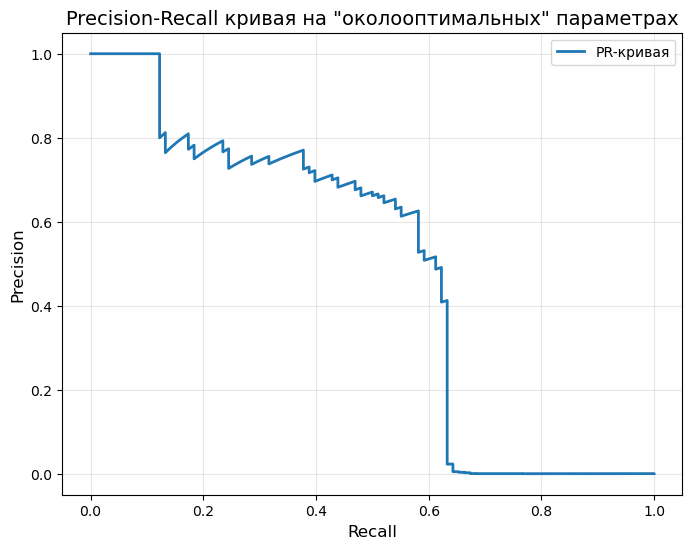

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
y_proba = log_reg.predict_proba(X_test_2_scaled)

# Строим PR-кривую через sklearn для модели с не подобранными гиперпараметрами
precision, recall, thresholds = precision_recall_curve(y_test_2, y_proba)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, linewidth=2, label='PR-кривая')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall кривая на "околооптимальных" параметрах', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## "Умный" подбор гиперпараметров
При создании оптимальной модели линейной регрессии мы использовали GridSearchCV, который (особенно на больших данных)
работает довольно плохо. Попробуем подобрать гиперпараметры (l2, learning rate, threshold, n_steps) умным способом, который 
на основе предыдущих результатов сам решает, какие параметры пробовать дальше. В этом нам поможет Байесовский Оптимизатор Optuna
### Установка
Для установки: ``` !pip install optuna ```

In [10]:
!pip install optuna
import optuna

In [11]:
# Функция для одной попытки байесовского оптимизатора
def objective(trial):
    lr_suggest = trial.suggest_float('lr', 0.001, 0.2, log=True)
    l2_suggest = trial.suggest_float('l2', 0.0001, 0.2, log=True)
    n_steps_suggest = trial.suggest_int('n_steps', 1000, 2000,step= 100)
    threshold_suggest = trial.suggest_float('threshold', 0.01, 0.4, log=True)
    log_reg_suggest = LogisticRegressionMyOwn(lr=lr_suggest, l2=l2_suggest, n_steps=n_steps_suggest, threshold=threshold_suggest)
    log_reg_suggest.fit(X_train_2_scaled, y_train_2)
    return (log_reg_suggest.score(X_test_2_scaled, y_test_2))['f1_score']

### Подбор гиперпараметров
Так как здесь я оптимизирую свою далеко не самую быструю версию логистической регрессии, которая обучается на таком большом датасете с ```n_steps ~ 1500``` не менее 25 секунд, я не могу позволить себе более чем 50 trials, потому что на один "шаг" байесовского оптимизатора уходит слишком много времени. Для примера можно взять ```n_trials = 10```.  

In [12]:
# Подбор оптимальных гиперпараметров
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10, n_jobs=-1)
print(study.best_params)

[I 2026-07-15 02:13:34,796] A new study created in memory with name: no-name-ea3eec84-1016-4c91-bca5-62cb71d5ff40
[I 2026-07-15 02:15:05,180] Trial 4 finished with value: 0.004769840813746337 and parameters: {'lr': 0.00662943313683892, 'l2': 0.003053427025460836, 'n_steps': 1000, 'threshold': 0.03330733366703369}. Best is trial 4 with value: 0.004769840813746337.
[I 2026-07-15 02:15:06,376] Trial 0 finished with value: 0.00281216776981378 and parameters: {'lr': 0.0013057631447714046, 'l2': 0.0016111673998292799, 'n_steps': 1000, 'threshold': 0.3588870426203124}. Best is trial 4 with value: 0.004769840813746337.
[I 2026-07-15 02:15:06,658] Trial 8 finished with value: 0.007078656917990035 and parameters: {'lr': 0.011297672495190154, 'l2': 0.06555160939720947, 'n_steps': 1000, 'threshold': 0.07905343197968898}. Best is trial 8 with value: 0.007078656917990035.
[I 2026-07-15 02:15:31,775] Trial 3 finished with value: 0.0014537622829452147 and parameters: {'lr': 0.001891077626012724, 'l2':

{'lr': 0.11691556883611084, 'l2': 0.0004859697404401865, 'n_steps': 1600, 'threshold': 0.24857361183726276}


### Сравним насколько быстро обучится логистическая регрессия из sklearn и LogisticRegressionMyOwn на оптимальных параметрах и построим для них PR-кривые

In [13]:
%%time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Берём лучшие параметры из Optuna
params = study.best_params
#params = {'lr': 0.13007322160225865, 'l2': 0.008343038451693187, 'n_steps': 1400, 'threshold': 0.09299357897943601}

# Создаём модель sklearn
sk_log_reg = LogisticRegression(
    C=1 / params['l2'],         
    max_iter=params['n_steps'], 
    penalty='l2',
    random_state=42,
    solver='lbfgs'             
)

sk_log_reg.fit(X_train_2_scaled, y_train_2)

# Предсказания с порогом из Optuna
proba_sk = sk_log_reg.predict_proba(X_test_2_scaled)[:, 1]
preds_sk = (proba_sk >= params['threshold']).astype(int)

# Считаем метрики
metrics_sk = {
    'recall': recall_score(y_test_2, preds_sk),
    'precision': precision_score(y_test_2, preds_sk),
    'accuracy': accuracy_score(y_test_2, preds_sk),
    'f1_score': f1_score(y_test_2, preds_sk),
    'roc_auc': roc_auc_score(y_test_2, preds_sk)
}

print("Sklearn LogisticRegression:")
print(f"  recall    : {metrics_sk['recall']:.6f}")
print(f"  precision : {metrics_sk['precision']:.6f}")
print(f"  accuracy  : {metrics_sk['accuracy']:.6f}")
print(f"  f1_score  : {metrics_sk['f1_score']:.6f}")
print(f"  roc-auc   : {metrics_sk['roc_auc']:.6f}")

Sklearn LogisticRegression:
  recall    : 0.714286
  precision : 0.729167
  accuracy  : 0.999052
  f1_score  : 0.721649
  roc-auc   : 0.856914
CPU times: total: 359 ms
Wall time: 361 ms


In [14]:
%%time
my_log_reg = LogisticRegressionMyOwn(
    lr=params['lr'],
    l2=params['l2'],
    n_steps=params['n_steps'],
    threshold=params['threshold']
)

my_log_reg.fit(X_train_2_scaled, y_train_2)
metrics_my = my_log_reg.score(X_test_2_scaled, y_test_2)

print("MyOwn LogisticRegression:")
print(f"  recall    : {metrics_my['recall']:.6f}")
print(f"  precision : {metrics_my['precision']:.6f}")
print(f"  accuracy  : {metrics_my['accuracy']:.6f}")
print(f"  f1_score  : {metrics_my['f1_score']:.6f}")

MyOwn LogisticRegression:
  recall    : 0.704082
  precision : 0.802326
  accuracy  : 0.999192
  f1_score  : 0.750000
CPU times: total: 22.3 s
Wall time: 22.3 s


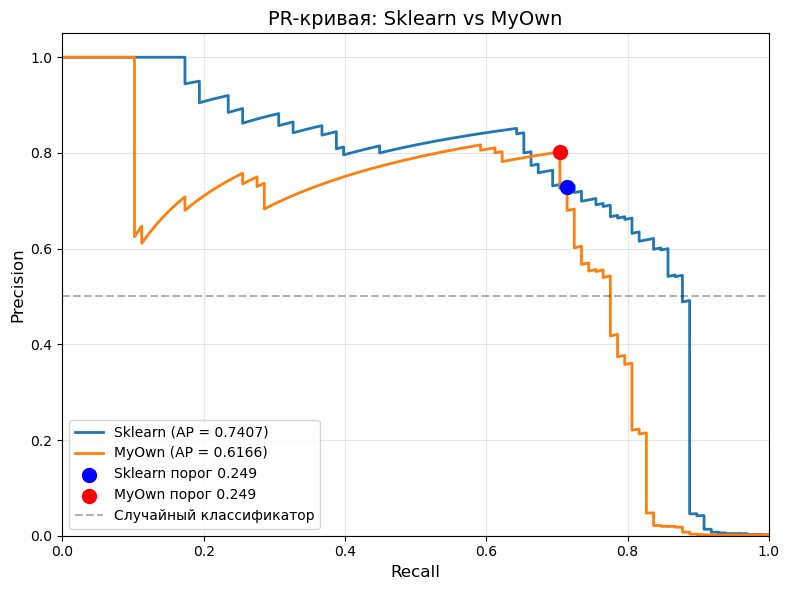

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# Берём вероятности из уже обученных моделей
proba_sk = sk_log_reg.predict_proba(X_test_2_scaled)[:, 1]
proba_my = my_log_reg.predict_proba(X_test_2_scaled)

# Считаем PR-кривые
precision_sk, recall_sk, _ = precision_recall_curve(y_test_2, proba_sk)
precision_my, recall_my, _ = precision_recall_curve(y_test_2, proba_my)

ap_sk = average_precision_score(y_test_2, proba_sk)
ap_my = average_precision_score(y_test_2, proba_my)

# Рисуем
plt.figure(figsize=(8, 6))

plt.plot(recall_sk, precision_sk, label=f'Sklearn (AP = {ap_sk:.4f})', linewidth=2)
plt.plot(recall_my, precision_my, label=f'MyOwn (AP = {ap_my:.4f})', linewidth=2)

# Точка с порогом для Sklearn
threshold = params['threshold']
preds_sk = (proba_sk >= threshold).astype(int)
preds_my = my_log_reg.predict(X_test_2_scaled)

from sklearn.metrics import precision_score, recall_score
p_sk = precision_score(y_test_2, preds_sk)
r_sk = recall_score(y_test_2, preds_sk)
p_my = precision_score(y_test_2, preds_my)
r_my = recall_score(y_test_2, preds_my)

plt.scatter(r_sk, p_sk, color='blue', s=100, label=f'Sklearn порог {threshold:.3f}', zorder=5)
plt.scatter(r_my, p_my, color='red', s=100, label=f'MyOwn порог {threshold:.3f}', zorder=5)

plt.plot([0, 1], [0.5, 0.5], 'k--', alpha=0.3, label='Случайный классификатор')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('PR-кривая: Sklearn vs MyOwn', fontsize=14)
plt.legend(loc='lower left', fontsize=10)
plt.grid(alpha=0.3)
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.tight_layout()
plt.show()

### Вывод
Этот датасет довольно интересен, он требует понимания того, как нужно преобразовать признаки ```Amount``` и ```Time``` (к слову остальные 28 признаков - **главные компоненты** (т.е. попарно ортогональные вектора, а значит можно задуматься о том что регуляризация вовсе не нужна, ведь корреляция между ортогональными векторами равна 0)), и, самое главное, понимание того какую метрику мы хотим улучшать при таком большом дизбалансе классов.

Например ```PR-кривая``` хорошо показывает какой баланс между ```precision``` и ```recall``` может быть достигнут, а ```roc-auc``` и ```accuracy``` не значат ровным счетом ничего (нетрудно понять что модель предсказывающая 0 всегда имела бы большой score по этим метрикам). Разумеется нельзя говорить про все транзакции что они мошеннические *(FP)*, но и пропускать мошенников плохо *(FN)*, поэтому в таких задачах важно смотреть на баланс между precision и recall - на ```f1_score```. 

Как видно обе модели хорошо справились с задачей, не переобучились и почти не потребовали регуляризацию. Поэтому во многих банках до сих пор используют Логистическую регрессию - из-за простоты и хорошей интерпретируемости. И в конце концов в задаче детекции мошеннических транзакций врядли часто встречаются сложные формы классов (полумесяцы, концентрические окружности) которые потребовали бы *SVM-а* или *нейросетей*, так что логистической регрессии часто хватает.